In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

import warnings
# Specifically ignore Deprecation Warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Ignore future warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/houses-in-london/london_houses.csv


## Data Understanding

In [2]:
data = pd.read_csv('/kaggle/input/houses-in-london/london_houses.csv')
data.head()

,Address,Neighborhood,Bedrooms,Bathrooms,Square Meters,Building Age,Garden,Garage,Floors,Property Type,Heating Type,Balcony,Interior Style,View,Materials,Building Status,Price (£)
0,78 Regent Street,Notting Hill,2,3,179,72,No,No,3,Semi-Detached,Electric Heating,High-level Balcony,Industrial,Garden,Marble,Renovated,2291200
1,198 Oxford Street,Westminster,2,1,123,34,Yes,No,1,Apartment,Central Heating,High-level Balcony,Industrial,City,Laminate Flooring,Old,1476000
2,18 Regent Street,Soho,5,3,168,38,No,Yes,3,Semi-Detached,Central Heating,No Balcony,Industrial,Street,Wood,Renovated,1881600
3,39 Piccadilly Circus,Islington,5,1,237,53,Yes,Yes,1,Apartment,Underfloor Heating,No Balcony,Classic,Park,Granite,Renovated,1896000
4,116 Fleet Street,Marylebone,4,1,127,23,No,Yes,2,Semi-Detached,Central Heating,No Balcony,Modern,Park,Wood,Old,1524000


In [3]:
data.shape

(1000, 17)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Address          1000 non-null   object
 1   Neighborhood     1000 non-null   object
 2   Bedrooms         1000 non-null   int64 
 3   Bathrooms        1000 non-null   int64 
 4   Square Meters    1000 non-null   int64 
 5   Building Age     1000 non-null   int64 
 6   Garden           1000 non-null   object
 7   Garage           1000 non-null   object
 8   Floors           1000 non-null   int64 
 9   Property Type    1000 non-null   object
 10  Heating Type     1000 non-null   object
 11  Balcony          1000 non-null   object
 12  Interior Style   1000 non-null   object
 13  View             1000 non-null   object
 14  Materials        1000 non-null   object
 15  Building Status  1000 non-null   object
 16  Price (£)        1000 non-null   int64 
dtypes: int64(6), object(11)
memory usa

In [5]:
data.isna().sum()

Address            0
Neighborhood       0
Bedrooms           0
Bathrooms          0
Square Meters      0
Building Age       0
Garden             0
Garage             0
Floors             0
Property Type      0
Heating Type       0
Balcony            0
Interior Style     0
View               0
Materials          0
Building Status    0
Price (£)          0
dtype: int64

In [6]:
cat=[]
for col in data.columns:
    if data[col].dtype == 'object':
        cat.append(col)
print(cat)

cont = [col for col in data.columns if col not in cat]
cont

['Address', 'Neighborhood', 'Garden', 'Garage', 'Property Type', 'Heating Type', 'Balcony', 'Interior Style', 'View', 'Materials', 'Building Status']


['Bedrooms',
 'Bathrooms',
 'Square Meters',
 'Building Age',
 'Floors',
 'Price (£)']

## EDA

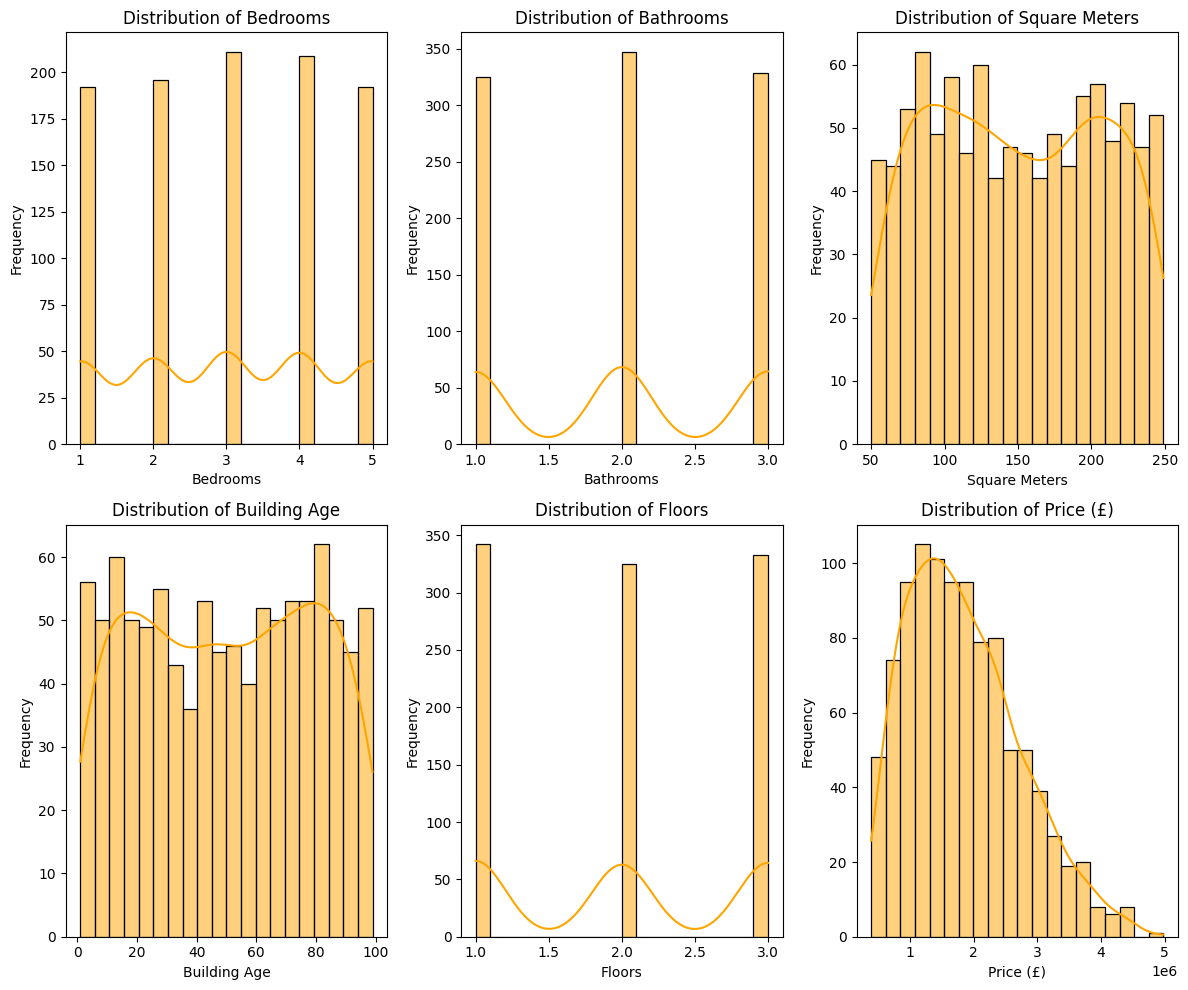

In [7]:
# Create distribution plots
plt.figure(figsize=(12, 10))
for i, col in enumerate(cont, start=1):
    plt.subplot(2, 3, i)
    sns.histplot(data[col], kde=True, bins=20, color="orange")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

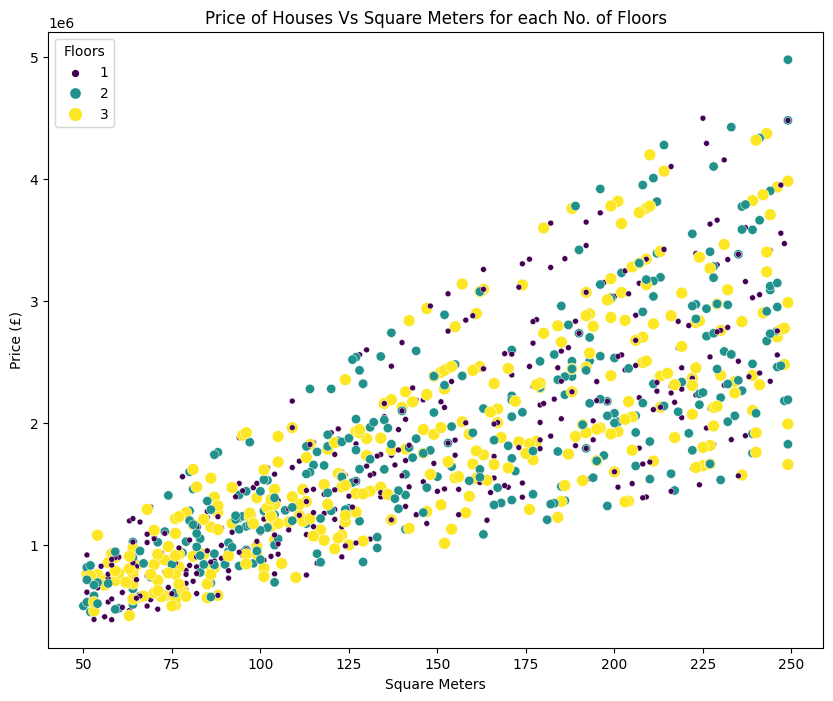

In [8]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=data, x='Square Meters',y='Price (£)',hue='Floors',size='Floors',palette='viridis')
plt.title("Price of Houses Vs Square Meters for each No. of Floors")
plt.show()

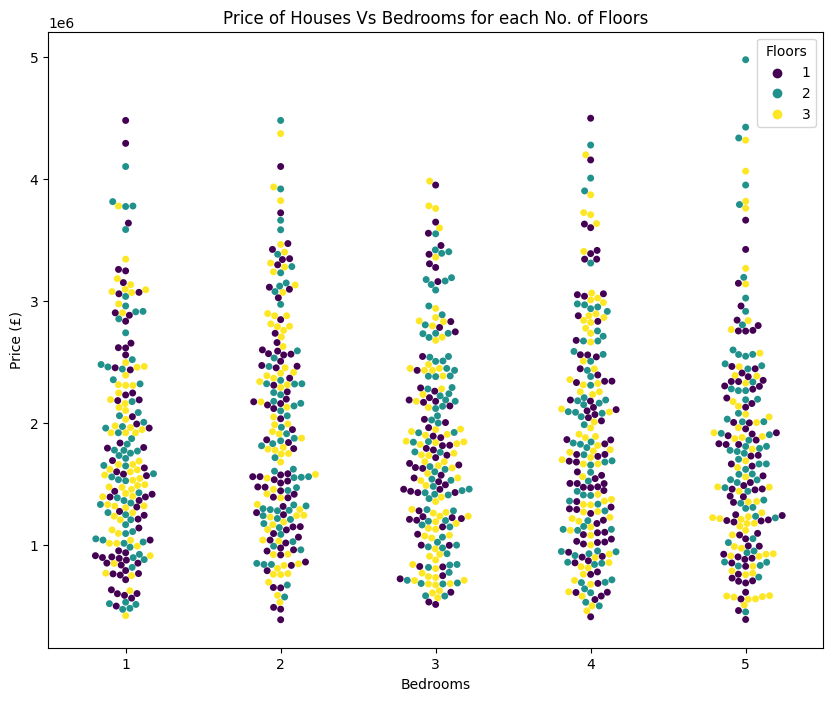

In [9]:
plt.figure(figsize=(10, 8))
sns.swarmplot(data=data, x='Bedrooms',y='Price (£)',palette='viridis',hue='Floors')#,palette='deep') '#1a843f'
plt.title("Price of Houses Vs Bedrooms for each No. of Floors")
plt.show()

<Figure size 1000x800 with 0 Axes>

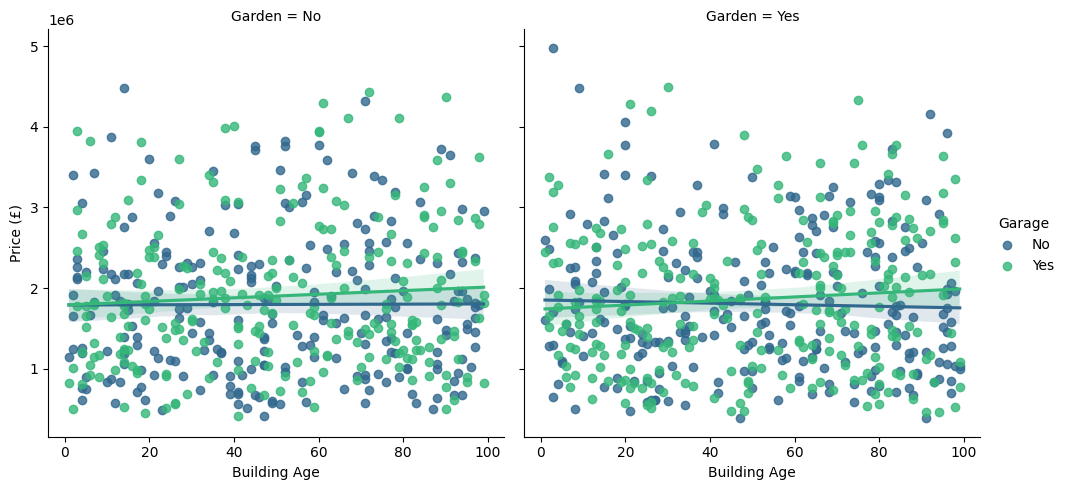

In [10]:
plt.figure(figsize=(10, 8))
sns.lmplot(data=data, x='Building Age',y='Price (£)',hue='Garage',col='Garden',palette='viridis')
plt.show()


<Figure size 2000x1500 with 0 Axes>

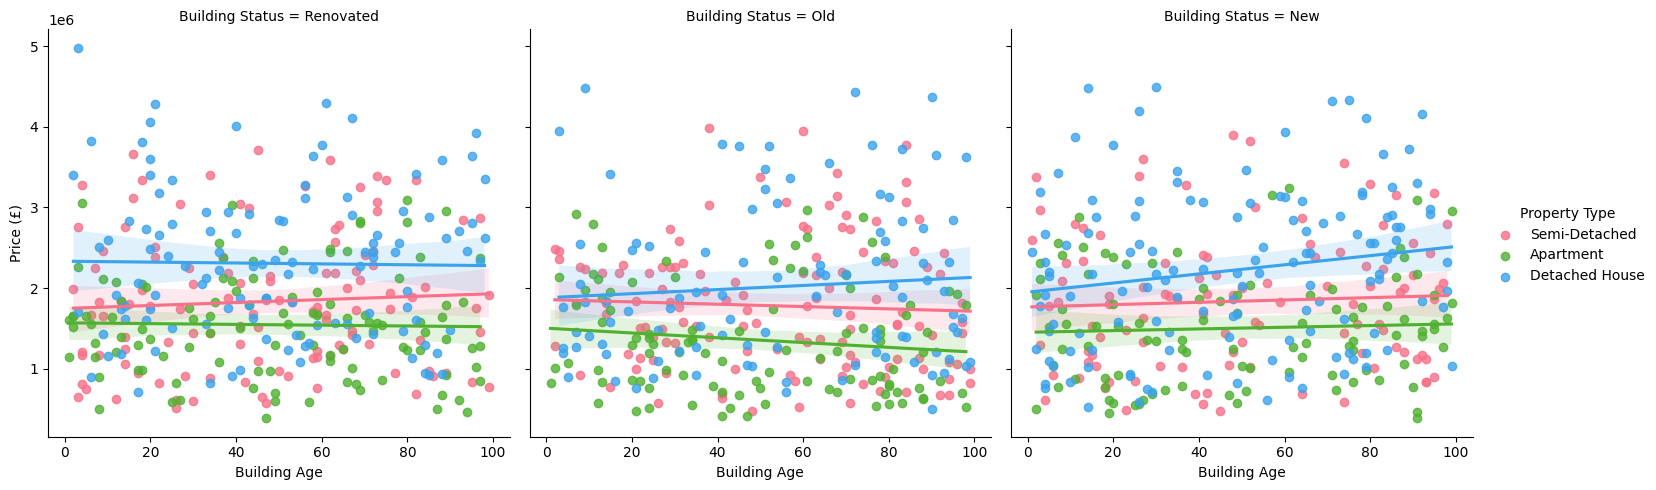

In [11]:
plt.figure(figsize=(20, 15))
sns.lmplot(data=data, x='Building Age',y='Price (£)',col='Building Status',hue='Property Type',palette='husl')#,size='Bedrooms')
plt.show()

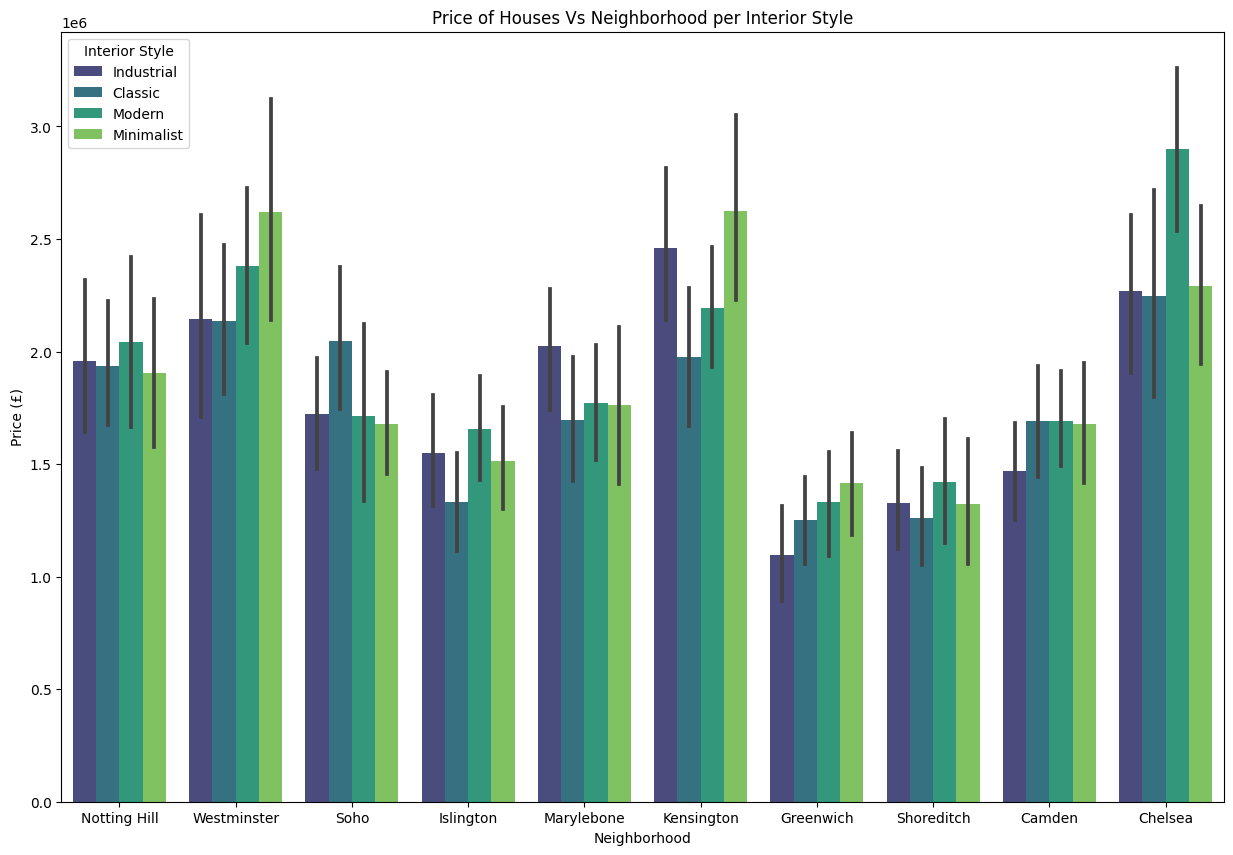

In [12]:
plt.figure(figsize=(15, 10))
sns.barplot(data=data, x='Neighborhood',y='Price (£)',palette='viridis',hue='Interior Style')#,hue='Floors',size='Floors',palette='deep')
plt.title("Price of Houses Vs Neighborhood per Interior Style")
plt.show()

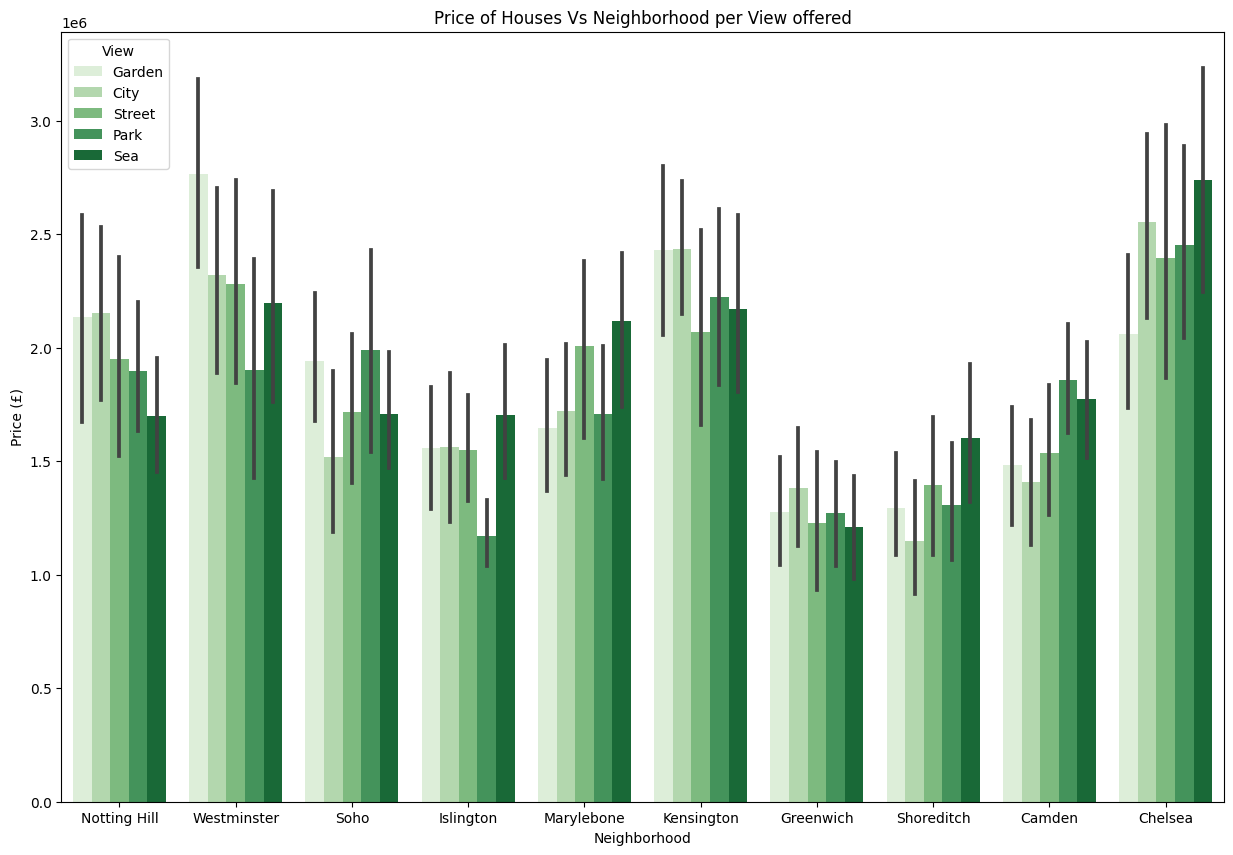

In [13]:
plt.figure(figsize=(15, 10))
sns.barplot(data=data, x='Neighborhood',y='Price (£)',palette='Greens',hue='View')#,hue='Floors',size='Floors',palette='deep')
plt.title("Price of Houses Vs Neighborhood per View offered")
plt.show()

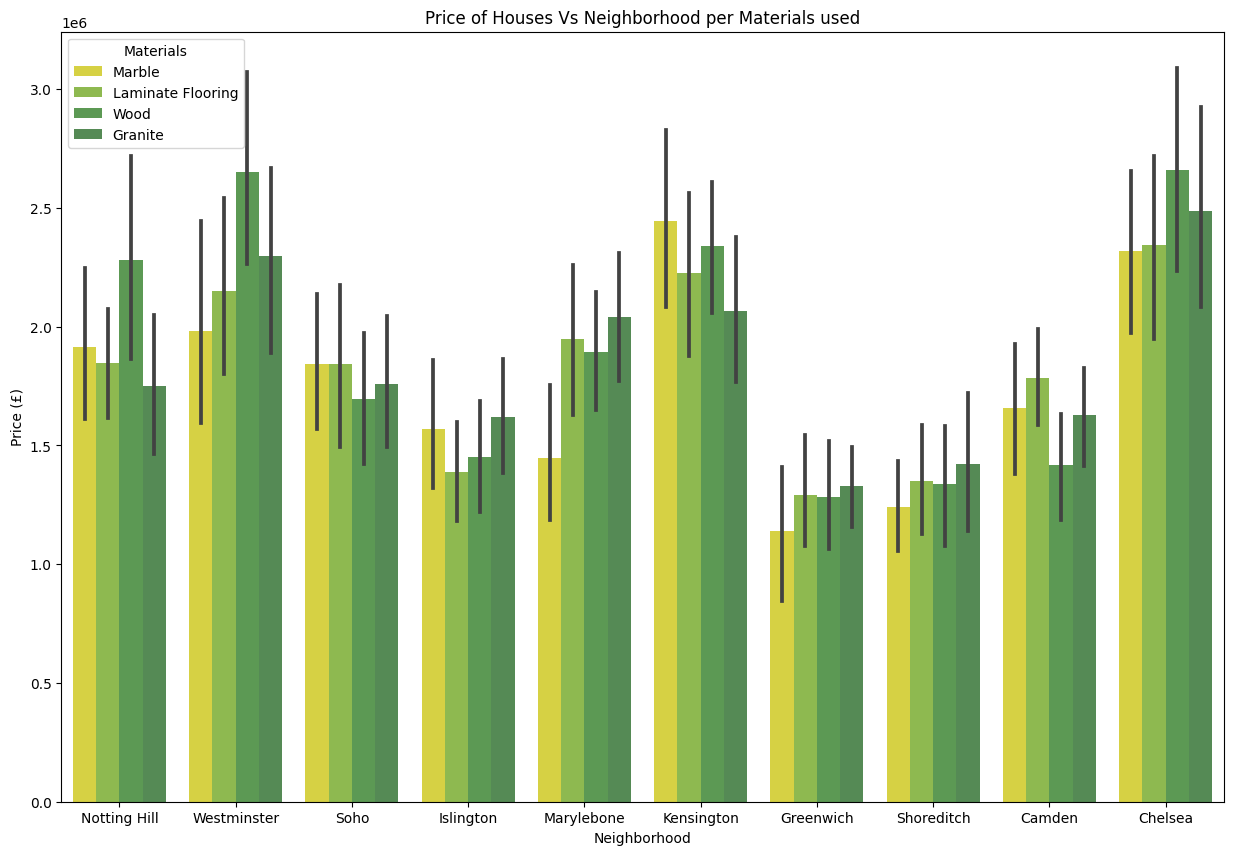

In [14]:
colors=['#eee82c', '#91cb3e', '#53a548', '#4c934c', '#19381f']
plt.figure(figsize=(15, 10))
sns.barplot(data=data, x='Neighborhood',y='Price (£)',palette=colors,hue='Materials')#,hue='Floors',size='Floors',palette='deep')
plt.title("Price of Houses Vs Neighborhood per Materials used")
plt.show()

## Regression - Random Forest

In [15]:
#encoding categorical variables
def dummies(df,cols):
    for col in cols:
        dummies = pd.get_dummies(df[col],dtype=int,prefix=col)
        df = pd.concat([df,dummies],axis=1)
        df = df.drop(labels=col, axis=1)
    return df

data = dummies(data,cat)

In [16]:
#Function to plot regression results
def plot_reg_results(y_test,y_pred):
    plt.scatter(y_test, y_pred,c=abs(y_test - y_pred) ,cmap='viridis', label='Error Magnitude',alpha=0.5)
    plt.plot(
    [y_test.min(), y_test.max()], 
    [y_test.min(), y_test.max()], 
    'k--', 
    lw=2, 
    label='Perfect Prediction')
    plt.show()

In [17]:
X = data.drop('Price (£)',axis=1)
y = data['Price (£)']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape,X_test.shape)

(800, 815) (200, 815)


Root Mean Squared Error (RMSE): 181384.67847747827
R2 Score: 0.9591579480761865
Adjusted R-squared: 1.0131941044364268


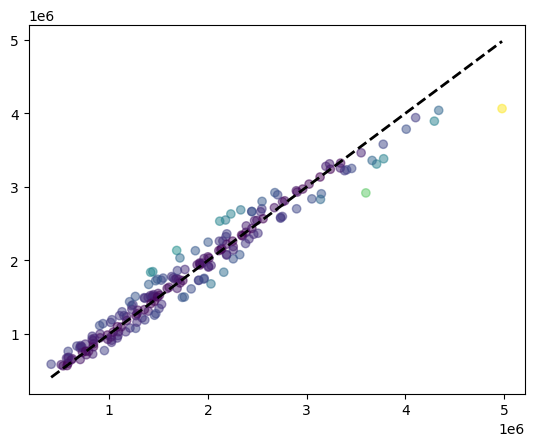

In [18]:
#Random Forest
RF = RandomForestRegressor()
model_rf = RF.fit(X_train,y_train)
y_rf_pred = model_rf.predict(X_test)

rf_mse = mean_squared_error(y_test, y_rf_pred)
rf_rmse = rf_mse ** 0.5
print("Root Mean Squared Error (RMSE):", rf_rmse)

rf_r2 = r2_score(y_test, y_rf_pred)
print(f"R2 Score: {rf_r2}")

n = len(y_test)  # Number of samples
k = X_test.shape[1]  # Number of independent variables
adjusted_r2 = 1 - ((1 - rf_r2) * (n - 1) / (n - k - 1))
print("Adjusted R-squared:", adjusted_r2)

plot_reg_results(y_test,y_rf_pred)

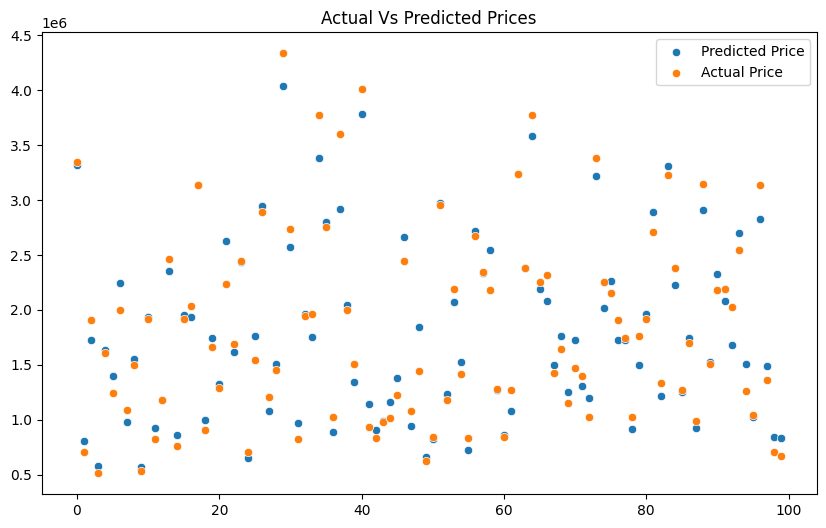

In [19]:
plt.figure(figsize=(10,6))
sns.scatterplot(y_rf_pred[:100],label = 'Predicted Price')
sns.scatterplot(y_test.values[:100],label = 'Actual Price')
plt.title("Actual Vs Predicted Prices")
plt.show()